# Telco Customer Churn: Model Training and Evaluation

This notebook builds a model that predicts whether a telecom customer will leave (churn). It compares a few models, picks the best one, and checks how well it works on customers it has never seen.

**The steps are:**
1. Import the tools we need and load the cleaned data.
2. Set the main settings in one place.
3. Separate the inputs from the target and split the data into training and test sets.
4. Build a preprocessing pipeline and compare candidate models with cross-validation.
5. Pick the best model, train it, and test it on the held-out test set.
6. Show the results in a table and in charts.

## 1. Import Libraries

This cell brings in everything the notebook needs. The imports are grouped by purpose:

- **General tools:** `numpy` for numbers, `pandas` for tables, and `matplotlib` for charts.
- **Data splitting and cross-validation:** tools to split the data and to test a model on several different parts of it.
- **Preprocessing:** tools to prepare the data. `StandardScaler` puts numbers on the same scale. `OneHotEncoder` turns categories into numbers. `ColumnTransformer` applies different steps to different columns. `Pipeline` joins the preprocessing and the model into one workflow.
- **Models:** `LogisticRegression` and `RandomForestClassifier` are the two real models. `DummyClassifier` is a very simple baseline. We use it to check that our real models learn something useful.
- **Evaluation metrics:** accuracy, precision, recall, F1, and the confusion matrix, which are used to judge the predictions.

In [11]:
# General data science libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data splitting and cross-validation
from sklearn.model_selection import (
    train_test_split,   # Split the data into training and testing sets
    cross_validate,     # Evaluate a model using cross-validation
    StratifiedKFold     # Cross-validation that keeps class proportions
)

# Data preprocessing
from sklearn.preprocessing import (
    StandardScaler,     # Puts numerical features on a common scale
    OneHotEncoder       # Turns categories into numerical columns
)
from sklearn.compose import ColumnTransformer   # Different steps for different columns
from sklearn.pipeline import Pipeline           # Preprocessing and model in one workflow

# Classification models
from sklearn.linear_model import LogisticRegression   # Predicts the probability of churn
from sklearn.ensemble import RandomForestClassifier   # Combines many decision trees
from sklearn.dummy import DummyClassifier             # Simple baseline for comparison

# Classification evaluation metrics
from sklearn.metrics import (
    accuracy_score,         # Share of all predictions that are correct
    precision_score,        # Of predicted churners, how many really churned
    recall_score,           # Of real churners, how many we found
    f1_score,               # Balance of precision and recall
    confusion_matrix,       # Table of correct and wrong predictions
    ConfusionMatrixDisplay, # Chart of the confusion matrix
    make_scorer             # Turns a metric into a scorer for cross-validation
)

## 2. Load the Data

We load the cleaned Telco churn dataset into a pandas DataFrame called `df`. The file `telco_churn_cleaned.csv` must be in the same folder as this notebook.

In [12]:
df = pd.read_csv("telco_churn_cleaned.csv")

## 3. Model Configuration

Here we keep all the main settings in one place so they are easy to find and change.

| Setting | Value | Meaning |
|---|---|---|
| `TASK` | `"classification"` | We predict one of two classes: `No` (stays) or `Yes` (churns). |
| `TARGET` | `"Churn"` | The column we want the model to predict. It must match the column name in the dataset. |
| `TEST_SIZE` | `0.20` | 20% of the data is set aside as the test set. |
| `K` | `5` | The number of folds used in cross-validation. |
| `SEED` | `42` | A fixed number that makes random steps give the same result every time. |

In [13]:
TASK = "classification"   # Two classes: No = non-churner, Yes = churner
TARGET = "Churn"          # Column the model will predict
TEST_SIZE = 0.20          # Share of data kept aside for testing
K = 5                     # Number of cross-validation folds
SEED = 42                 # Makes random steps reproducible

## 4. Prepare Features and Target

Before building a model, we separate the data into the **inputs** (`X`) and the **target** (`y`). We also find out which columns are numbers and which are categories, because they need different preprocessing later.

What this cell does:
- **Missing value check:** it stops the notebook if any missing values remain. They must be handled before we continue.
- **`X` (features):** all the columns the model uses to predict churn. We remove the target column, because the model must predict it and not see it. We also remove `customerID`, because an ID does not help predict churn.
- **`y` (target):** the `Churn` column, which says if each customer churned.
- **`num_cols` and `cat_cols`:** the lists of numerical and categorical columns. Numbers will be scaled. Categories will be one-hot encoded.

The printed line shows how many columns of each type we have.

In [14]:
# Stop here if any missing values remain
assert df.isna().sum().sum() == 0, "Missing values remain; handle them first."

# Features: drop the target and the customer ID
X = df.drop(columns=[TARGET, "customerID"])

# Target: whether the customer churned
y = df[TARGET]

# Split the feature names by type
num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()

print(f"Numeric: {len(num_cols)} | Categorical: {len(cat_cols)}")

Numeric: 4 | Categorical: 15


## 5. Split into Training and Test Sets

We divide the data into two parts:

- **Training set:** the data the model learns from.
- **Test set:** data that is kept hidden. It is not used to train or to choose the model. At the end, it tells us how the final model performs on customers it has never seen.

How the split works:
- `test_size=TEST_SIZE` means about 80% of the rows go to training and 20% go to testing.
- `stratify=y` keeps the same share of churners and non-churners in both sets. This matters a lot when one class is much smaller than the other.
- `random_state=SEED` makes the split the same every time we run the code.

The printed line shows the number of rows in each set.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y
)

print(f"Train rows: {len(X_train)} | Test rows: {len(X_test)}")

Train rows: 5634 | Test rows: 1409


## 6. Build the Preprocessing Pipeline

The model cannot use the raw data directly, because it has both numerical and categorical columns. So we prepare them in two ways:

- **Numerical columns** are standardized, so all values sit on a common scale.
- **Categorical columns** are one-hot encoded, so each category becomes its own numerical column. `handle_unknown="ignore"` stops errors if a new category appears later.

The function `make(model)` joins this preprocessing and a model into one `Pipeline`. Every candidate model then gets exactly the same preprocessing.

**Why use a pipeline?** In cross-validation, the preprocessing must learn only from the training part of each fold. If we prepared all the training data first, information from the validation data could leak in. That would make the results look better than they really are.

In [ ]:
prep = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

def make(model):
    # Preprocessing followed by the model
    return Pipeline([
        ("prep", prep),
        ("model", model)
    ])

## 7. Set Up Cross-Validation

Cross-validation tests a model on several different parts of the training data. This gives a more reliable picture than a single test.

- We use `StratifiedKFold` instead of normal K-fold. It keeps the share of churners and non-churners about the same in every fold.
- `shuffle=True` mixes the rows before the folds are made, and `random_state=SEED` keeps the folds the same each run.
- `n_splits=K` sets the number of folds. With `K = 5`, each row is used for validation once and for training four times.

In [ ]:
cv = StratifiedKFold(
    n_splits=K,
    shuffle=True,
    random_state=SEED
)

## 8. Define the Scoring Metrics

We measure each model with four metrics: accuracy, precision, recall, and F1.

In this project, `"Yes"` (the customer churned) is the **positive class**. Scikit-learn assumes the positive class is `1` by default. Our classes are the words `"No"` and `"Yes"`, so we set `pos_label="Yes"` to tell it which class to focus on.

We also set `zero_division=0`. If a model makes no positive predictions in a fold, the score becomes 0 instead of causing a warning that interrupts the run.

In [ ]:
scoring = {
    "accuracy": "accuracy",

    "precision": make_scorer(
        precision_score,
        pos_label="Yes",
        zero_division=0
    ),

    "recall": make_scorer(
        recall_score,
        pos_label="Yes",
        zero_division=0
    ),

    "f1": make_scorer(
        f1_score,
        pos_label="Yes",
        zero_division=0
    )
}

## 9. Choose the Main Metric

**F1** is the main metric we use to compare models.

There are many more non-churners than churners in the data, so accuracy alone can be misleading. F1 balances precision and recall for the positive class, which is the customer who churned. A higher F1 score means better performance.

In [ ]:
primary = "f1"
higher_better = True

## 10. Define the Candidate Models

We compare three models:

- **Dummy (reference):** a simple baseline that always predicts the most common class. It learns nothing about the features. We use it as a reference point.
- **Logistic Regression:** a simple model that learns how the features relate to the chance of churn.
- **Random Forest:** a model made of many decision trees. It can learn more complex patterns.

All three use the same preprocessing, so the comparison is fair.

In [ ]:
candidates = {
    "Dummy (reference)": make(
        DummyClassifier(strategy="most_frequent")
    ),

    "Logistic Regression": make(
        LogisticRegression(max_iter=1000)
    ),

    "Random Forest": make(
        RandomForestClassifier(random_state=SEED)
    )
}

## 11. Run Cross-Validation

We now run cross-validation on each candidate model.

- Only the **training data** is used. The test set stays untouched until the very end.
- For each model, `cross_validate` trains the full pipeline on the training part of each fold and scores it on the validation part.
- We save the score of every fold. This lets us look at both the average score and how much it changes between folds.

The printed lines show the mean and standard deviation of the F1 score for each model. A small standard deviation means the scores were steady across folds.

In [16]:
cv_results = {}

for name, pipe in candidates.items():
    res = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring
    )

    cv_results[name] = {}

    for metric in scoring:
        cv_results[name][metric] = res[f"test_{metric}"]

    primary_scores = cv_results[name][primary]

    print(
        f"{name:22s} "
        f"CV {primary}: "
        f"mean={primary_scores.mean():.4f}  "
        f"std={primary_scores.std():.4f}"
    )

Dummy (reference)      CV f1: mean=0.0000  std=0.0000
Logistic Regression    CV f1: mean=0.5923  std=0.0299
Random Forest          CV f1: mean=0.5394  std=0.0290


## 12. Select the Best Model

We pick the real model with the highest average F1 score from cross-validation.

The Dummy model is left out. It is only a baseline and we would never use it in practice. Among the other models, the one with the best mean F1 score is selected and its name is printed.

In [17]:
# Leave out the Dummy baseline
real = {
    name: results
    for name, results in cv_results.items()
    if not name.startswith("Dummy")
}

# Pick the model with the highest mean F1
pick = max(
    real,
    key=lambda name: real[name][primary].mean()
)

print(f"Selected model: {pick}")

Selected model: Logistic Regression


## 13. Train the Final Model and Make Predictions

The model was chosen using cross-validation, but it was not yet trained on all of the training data. Here we fit the selected model on the whole training set (`X_train` and `y_train`).

Then we use the test set for the first time, to predict churn for customers the model has never seen. We also train the Dummy baseline the same way, so we can compare the two on the same test data.

In [ ]:
# Train the selected model and predict on the test set
final = candidates[pick].fit(X_train, y_train)
y_pred = final.predict(X_test)

# Train the Dummy baseline and predict on the test set
ref = candidates["Dummy (reference)"].fit(X_train, y_train)
y_ref = ref.predict(X_test)

## 14. Define the Scoring Function

The function `score` calculates the four metrics for a set of predictions. `"Yes"` is the positive class, because it means the customer churned.

- **Accuracy:** the share of all predictions that are correct.
- **Precision:** of the customers predicted to churn, how many really churned.
- **Recall:** of the customers who really churned, how many the model found.
- **F1:** one number that combines precision and recall.

We use the same function for the selected model and the Dummy baseline, so the comparison is fair.

In [ ]:
def score(y_true, y_hat):
    return {
        "accuracy": accuracy_score(y_true, y_hat),

        "precision": precision_score(
            y_true,
            y_hat,
            pos_label="Yes",
            zero_division=0
        ),

        "recall": recall_score(
            y_true,
            y_hat,
            pos_label="Yes",
            zero_division=0
        ),

        "f1": f1_score(
            y_true,
            y_hat,
            pos_label="Yes",
            zero_division=0
        )
    }

## 15. Calculate the Test Scores

We now work out the final test scores for the selected model and for the Dummy baseline. Neither model was trained on the test data, so these scores show how well the selected model handles new customers.

In [18]:
test_scores = score(y_test, y_pred)
ref_scores = score(y_test, y_ref)

## 16. Results Table

This table puts the cross-validation results and the test results for the selected model side by side. It covers all four metrics.

- **CV mean:** the average score across the cross-validation folds.
- **CV std:** how much the score changed between folds. A smaller value means more consistent results.
- **Test:** the score on the held-out test set. This is the final check on unseen data.
- **Reference:** the score of the Dummy baseline on the same test set. The selected model should beat it.

In [19]:
table = pd.DataFrame({
    "CV mean": {
        metric: cv_results[pick][metric].mean()
        for metric in scoring
    },

    "CV std": {
        metric: cv_results[pick][metric].std()
        for metric in scoring
    },

    "Test": test_scores,

    "Reference": ref_scores,
}).round(4)

print("\n", table)


            CV mean  CV std    Test  Reference
accuracy    0.8021  0.0118  0.8055     0.7346
precision   0.6529  0.0262  0.6572     0.0000
recall      0.5431  0.0411  0.5588     0.0000
f1          0.5923  0.0299  0.6040     0.0000


## 17. Visualize the Results

This cell draws three charts side by side to show how the selected model performs.

1. **Metric scores (bar chart):** compares the mean cross-validation score, the test score, and the Dummy baseline for each metric. It shows if the model is consistent and if it beats the baseline.
2. **Score per cross-validation fold (line chart):** shows the score from each fold. Points that sit close together mean the model is stable. Big gaps mean the score depends on which data was used for validation.
3. **Confusion matrix (test set):** rows are the real outcomes and columns are the predicted outcomes. It shows the number of correct non-churner predictions, false churn alarms, missed churners, and correctly found churners.

At the end, the layout is adjusted so the charts do not overlap, and the figure is saved as `model_metrics.png` for use in reports.

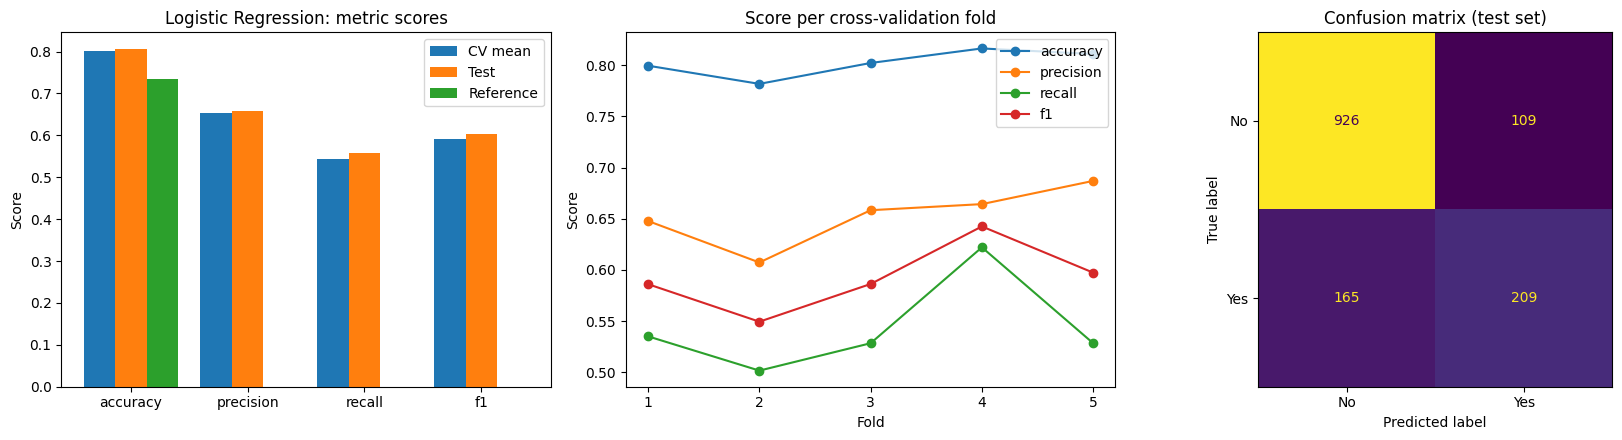

In [22]:
metrics = list(scoring.keys())

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 4.5)
)

# Plot 1: CV mean vs test vs Dummy baseline
x = np.arange(len(metrics))
w = 0.27

axes[0].bar(
    x - w,
    [table.loc[m, "CV mean"] for m in metrics],
    w,
    label="CV mean"
)

axes[0].bar(
    x,
    [table.loc[m, "Test"] for m in metrics],
    w,
    label="Test"
)

axes[0].bar(
    x + w,
    [table.loc[m, "Reference"] for m in metrics],
    w,
    label="Reference"
)

axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylabel("Score")
axes[0].set_title(f"{pick}: metric scores")
axes[0].legend()

# Plot 2: score on each cross-validation fold
folds = np.arange(1, K + 1)

for metric in metrics:
    axes[1].plot(
        folds,
        cv_results[pick][metric],
        marker="o",
        label=metric
    )

axes[1].set_xticks(folds)
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("Score")
axes[1].set_title("Score per cross-validation fold")
axes[1].legend()

# Plot 3: confusion matrix on the test set
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["No", "Yes"]
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
).plot(
    ax=axes[2],
    colorbar=False
)

axes[2].set_title("Confusion matrix (test set)")

# Fix the layout and save the figure
plt.tight_layout()
plt.savefig("model_metrics.png", dpi=150)
plt.show()